# 서울 지하철 이용자 예측 회귀 모델링

# 0. 라이브러리 불러오기

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# GPU가 있으면 GPU 사용, 없으면 CPU 사용
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("사용 장치:", device)

사용 장치: cpu


# 1. 데이터 로드

In [73]:
# 파일 위치 자동 탐색
import os
import glob

print("=== 현재 디렉토리 ===")
print(os.getcwd())

print("\n=== 현재 디렉토리 파일 목록 ===")
for item in os.listdir("."):
    print(item)

print("\n=== 상위 디렉토리 파일 목록 ===")
for item in os.listdir(".."):
    print(item)

# subway_train.csv 찾기
print("\n=== subway_train.csv 찾기 ===")
train_files = glob.glob("**/subway_train.csv", recursive=True)
print(f"찾은 파일: {train_files}")

if train_files:
    train_path = train_files[0]
    test_path = train_path.replace("train", "test")
    print(f"✅ Train 경로: {train_path}")
    print(f"✅ Test 경로: {test_path}")
    
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    
    print("\n✅ 파일 로드 성공!")
    print(f"Train shape: {train_df.shape}")
    print(f"Test shape: {test_df.shape}")
else:
    print("❌ subway_train.csv를 찾을 수 없습니다.")
    print("   현재 디렉토리:", os.getcwd())

=== 현재 디렉토리 ===
/content

=== 현재 디렉토리 파일 목록 ===
.config
drive
subway_pytorch_prediction.csv
sample_data

=== 상위 디렉토리 파일 목록 ===
proc
libx32
etc
root
mnt
home
tmp
lib64
sys
lib32
bin
opt
lib
run
usr
media
sbin
srv
dev
boot
var
content
kaggle
.dockerenv
datalab
tools
python-apt
python-apt.tar.xz

=== subway_train.csv 찾기 ===
찾은 파일: ['drive/MyDrive/subway_train.csv', 'drive/MyDrive/Colab Notebooks/subway_train.csv']
✅ Train 경로: drive/MyDrive/subway_train.csv
✅ Test 경로: drive/MyDrive/subway_test.csv

✅ 파일 로드 성공!
Train shape: (900, 8)
Test shape: (300, 8)


# 2. 결측치 처리

In [74]:
# 결측치 처리 - train 데이터
visibility_mean = train_df["visibility"].mean()
train_df["visibility"] = train_df["visibility"].fillna(visibility_mean)
train_df["station_name"] = train_df["station_name"].fillna("unknown")

# 결측치 처리 - test 데이터 (train의 통계로 처리)
test_df["visibility"] = test_df["visibility"].fillna(visibility_mean)
test_df["station_name"] = test_df["station_name"].fillna("unknown")

print("✅ 결측치 처리 완료!")
print("Train 결측치:")
print(train_df.isnull().sum())
print("\nTest 결측치:")
print(test_df.isnull().sum())

✅ 결측치 처리 완료!
Train 결측치:
date             0
day_of_week      0
month            0
station_name     0
visibility       0
precipitation    0
temperature      0
num_people       0
dtype: int64

Test 결측치:
date             0
day_of_week      0
month            0
station_name     0
visibility       0
precipitation    0
temperature      0
num_people       0
dtype: int64


# 3. 변수 정의

In [75]:
# 학습에 사용하지 않을 컬럼
COL_DEL = ["date"]

# 수치형 입력 변수
COL_NUM = ["visibility", "precipitation", "temperature"]

# 범주형 입력 변수
COL_CAT = ["day_of_week", "month", "station_name"]

# 예측 대상 컬럼
COL_Y = "num_people"

# 4. 간단한 데이터 시각화

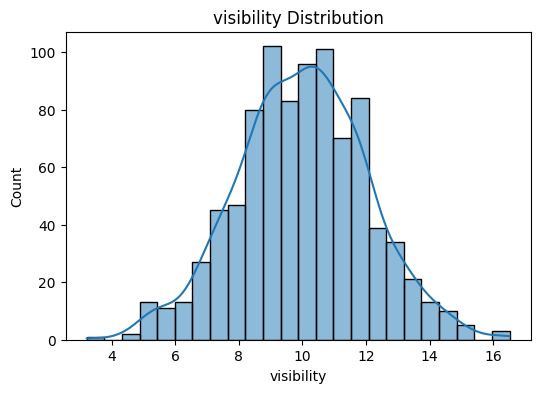

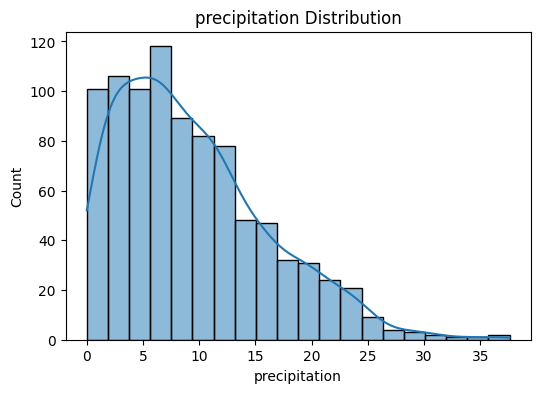

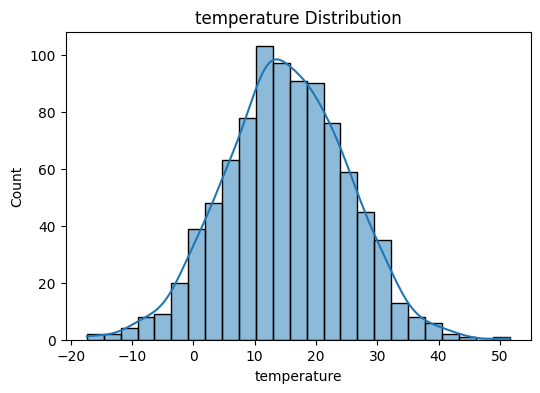

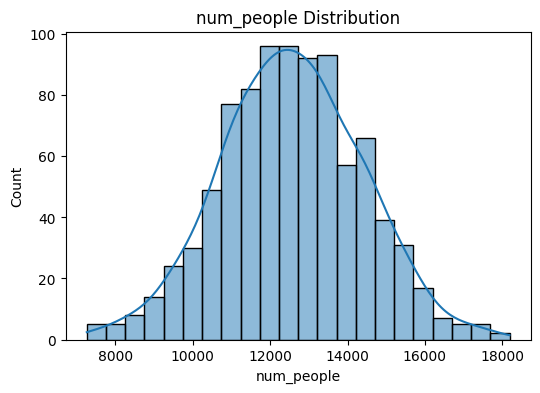

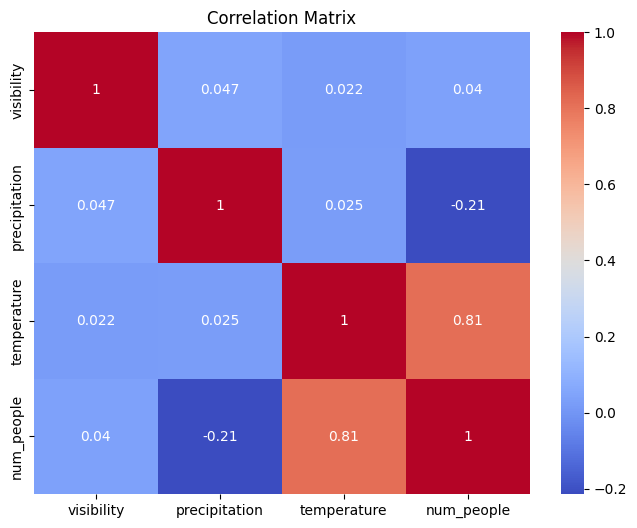

In [76]:
# 수치형 변수 분포 확인
for col in COL_NUM:
    plt.figure(figsize=(6, 4))
    sns.histplot(train_df[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

# 목표값 분포 확인
plt.figure(figsize=(6, 4))
sns.histplot(train_df[COL_Y], kde=True)
plt.title("num_people Distribution")
plt.show()

# 상관관계 확인
plt.figure(figsize=(8, 6))
sns.heatmap(train_df[COL_NUM + [COL_Y]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# 5. 이상값 처리 함수

In [ ]:
def handle_outliers_iqr(df, col, iqr_multiplier=1.0):
    """
    IQR 방식으로 이상값 처리
    iqr_multiplier: 기본 1.5 → 1.0 (더 엄격함) 또는 0.5 (매우 엄격함)
    """
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - iqr_multiplier * iqr
    upper_bound = q3 + iqr_multiplier * iqr
    
    # 이상값을 상한/하한으로 제한 (제거하지 않고 clipping)
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    
    return df


def handle_outliers_zscore(df, col, threshold=3):
    """
    Z-score 방식으로 이상값 처리
    threshold: 3 (기본) 또는 2.5 (더 엄격함)
    """
    mean = df[col].mean()
    std = df[col].std()
    
    z_scores = np.abs((df[col] - mean) / std)
    
    # 이상값을 mean ± threshold*std로 제한
    df[col] = np.where(
        z_scores > threshold,
        mean + threshold * std * np.sign(df[col] - mean),
        df[col]
    )
    
    return df


print("✅ 이상값 처리 함수 정의 완료!")
print("- handle_outliers_iqr: IQR 기반 (1.0 배수 사용 - 매우 엄격함)")
print("- handle_outliers_zscore: Z-score 기반 (3 배수 사용)")

# 6. 범주형 변수 라벨 인코딩

In [78]:
# 라벨 인코딩 - train 데이터
label_encoders = {}

for col in COL_CAT:
    le = LabelEncoder()
    
    # Train 데이터 fit_transform
    train_df[col] = le.fit_transform(train_df[col].astype(str))
    
    # Encoder 저장
    label_encoders[col] = le
    
    # Test 데이터에 같은 변환 적용
    test_df[col] = le.transform(test_df[col].astype(str))
    
    print(f"✅ {col} 인코딩 완료")

✅ day_of_week 인코딩 완료
✅ month 인코딩 완료
✅ station_name 인코딩 완료


# 7. 수치형 변수 스케일링

In [79]:
# 입력값 스케일러
x_scaler = StandardScaler()

# Train 데이터 fit_transform
train_df[COL_NUM] = x_scaler.fit_transform(train_df[COL_NUM])

# Test 데이터 transform (fit하지 않음!)
test_df[COL_NUM] = x_scaler.transform(test_df[COL_NUM])

# 목표값 스케일러 (train 데이터만)
y_scaler = StandardScaler()
train_df[[COL_Y]] = y_scaler.fit_transform(train_df[[COL_Y]])

print("✅ 스케일링 완료!")
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

✅ 스케일링 완료!
Train shape: (900, 8)
Test shape: (300, 8)


# 8. 학습 데이터와 검증 데이터 분리

In [80]:
# 입력 데이터 X 생성
X = train_df.drop(COL_DEL + [COL_Y], axis=1)

# 정답 데이터 y 생성
y = train_df[[COL_Y]]

# 학습용 80%, 검증용 20%로 분리
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

X_train shape: (720, 6)
X_val shape: (180, 6)
y_train shape: (720, 1)
y_val shape: (180, 1)


# 9. PyTorch Tensor 변환

In [81]:
# 입력 데이터는 실수형 float32로 변환
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32).to(device)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32).to(device)

# 정답 데이터도 회귀 문제이므로 float32 사용
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).to(device)

print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)

X_train_tensor: torch.Size([720, 6])
y_train_tensor: torch.Size([720, 1])


# 10. PyTorch 회귀 모델 정의

In [82]:
class SubwayRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        # 더 깊고 복잡한 모델 구조
        self.fc1 = nn.Linear(input_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)

        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)

        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)

        self.fc4 = nn.Linear(64, 32)
        self.bn4 = nn.BatchNorm1d(32)

        self.fc5 = nn.Linear(32, 16)
        self.bn5 = nn.BatchNorm1d(16)

        self.output = nn.Linear(16, 1)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.1)  # Dropout 감소 (0.2 → 0.1)

    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)

        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)

        x = self.relu(self.bn3(self.fc3(x)))
        x = self.dropout(x)

        x = self.relu(self.bn4(self.fc4(x)))
        x = self.dropout(x)

        x = self.relu(self.bn5(self.fc5(x)))

        x = self.output(x)
        return x


input_dim = X_train.shape[1]
model = SubwayRegressionModel(input_dim).to(device)

print("✅ 개선된 모델 생성!")
print(f"- 레이어 개수: 5개 (기존 3개에서 증가)")
print(f"- 뉴런 수: 256→128→64→32→16 (더 큰 용량)")
print(f"- Dropout: 0.1 (기존 0.2에서 감소)")
print(model)

✅ 개선된 모델 생성!
- 레이어 개수: 5개 (기존 3개에서 증가)
- 뉴런 수: 256→128→64→32→16 (더 큰 용량)
- Dropout: 0.1 (기존 0.2에서 감소)
SubwayRegressionModel(
  (fc1): Linear(in_features=6, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=64, out_features=32, bias=True)
  (bn4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc5): Linear(in_features=32, out_features=16, bias=True)
  (bn5): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (output): Linear(in_features=16, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.1, inplace=False)
)


# 11. 손실 함수와 최적화 함수 설정

In [83]:
# 최적화 재설정
criterion = nn.MSELoss()

# Adam 옵티마이저 (L2 정규화 추가)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# Learning Rate Scheduler 조정
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=500)

print("✅ 최적화 재설정!")
print("- Optimizer: Adam (L2 정규화 추가)")
print("- Learning Rate: 0.001")
print("- Scheduler: CosineAnnealingLR (코사인 방식으로 감소)")

✅ 최적화 재설정!
- Optimizer: Adam (L2 정규화 추가)
- Learning Rate: 0.001
- Scheduler: CosineAnnealingLR (코사인 방식으로 감소)


# 12. 모델 학습

In [ ]:
# 개선된 학습 루프
epochs = 1500

train_loss_history = []
val_loss_history = []
best_val_loss = float('inf')
patience = 50
patience_counter = 0

for epoch in range(epochs):
    # 모델을 학습 모드로 설정
    model.train()

    # 기울기 초기화
    optimizer.zero_grad()

    # 학습 데이터 예측
    y_pred = model(X_train_tensor)

    # 손실 계산
    loss = criterion(y_pred, y_train_tensor)

    # 역전파
    loss.backward()

    # 가중치 업데이트
    optimizer.step()

    # 손실 저장
    train_loss_history.append(loss.item())

    # 검증 단계
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_tensor)
        val_loss = criterion(val_pred, y_val_tensor)

    val_loss_history.append(val_loss.item())

    # Learning rate scheduler 업데이트
    scheduler.step()

    # Early Stopping (검증 손실이 개선되지 않으면 중단)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"\n⚠️ Early Stopping! (Epoch {epoch+1})")
        break

    # 100번마다 출력
    if (epoch + 1) % 100 == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {loss.item():.6f} "
            f"Val Loss: {val_loss.item():.6f}"
        )


Epoch [100/1500] Train Loss: 0.168180 Val Loss: 0.211367
Epoch [200/1500] Train Loss: 0.131888 Val Loss: 0.198272

⚠️ Early Stopping! (Epoch 211)
✅ 학습 완료!


# 13. 검증 데이터 평가

In [85]:
# 평가 모드
model.eval()

with torch.no_grad():
    # 검증 데이터 예측
    val_pred_scaled = model(X_val_tensor)

# Tensor를 NumPy 배열로 변환
val_pred_scaled = val_pred_scaled.cpu().numpy()
y_val_scaled = y_val_tensor.cpu().numpy()

# 스케일링된 예측값을 원래 이용자 수 단위로 복원
val_pred_original = y_scaler.inverse_transform(val_pred_scaled)

# 실제값도 원래 이용자 수 단위로 복원
y_val_original = y_scaler.inverse_transform(y_val_scaled)

# MSE 계산
mse = mean_squared_error(y_val_original, val_pred_original)

# R2 Score 계산
r2 = r2_score(y_val_original, val_pred_original)

print("PyTorch Regression Model")
print("MSE:", mse)
print("R2 Score:", r2)

PyTorch Regression Model
MSE: 657067.0
R2 Score: 0.8148584961891174


# 14. 학습 손실 시각화

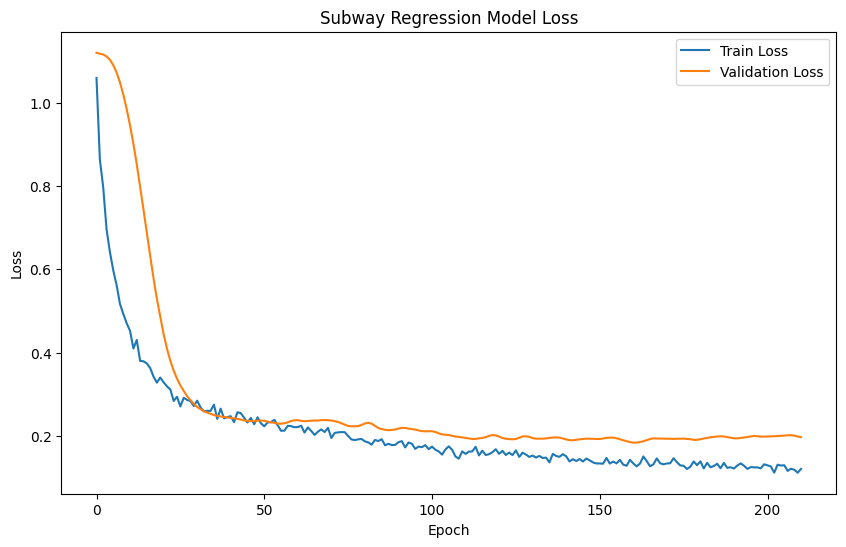

In [86]:
plt.figure(figsize=(10, 6))

# 학습 손실 그래프
plt.plot(train_loss_history, label="Train Loss")

# 검증 손실 그래프
plt.plot(val_loss_history, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Subway Regression Model Loss")
plt.legend()
plt.show()

# 15. 실제값과 예측값 비교 시각화

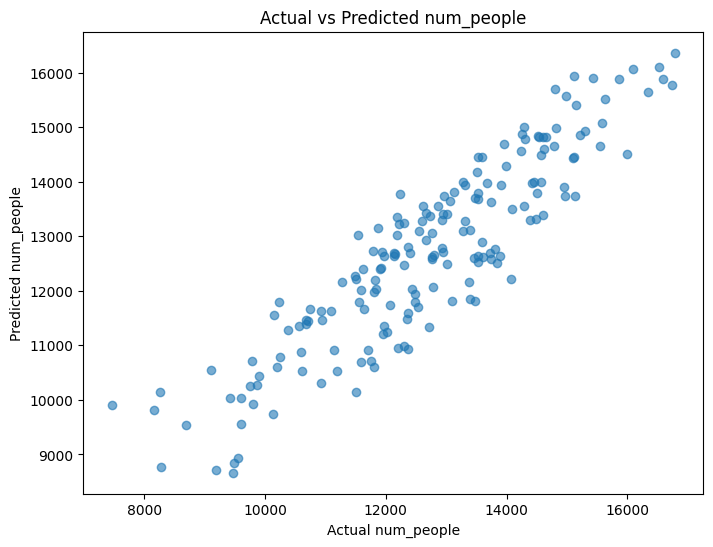

In [87]:
plt.figure(figsize=(8, 6))

# 실제값과 예측값 산점도
plt.scatter(y_val_original, val_pred_original, alpha=0.6)

plt.xlabel("Actual num_people")
plt.ylabel("Predicted num_people")
plt.title("Actual vs Predicted num_people")
plt.show()